In [17]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline 
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from matplotlib.patches import Circle, Rectangle, FancyBboxPatch, Ellipse
from matplotlib.lines import Line2D

# Set random seed for reproducibility
np.random.seed(2026)

from plotnine import * 
from plotnine.data import anscombe_quartet 
from plotnine.data import penguins 

p = ggplot(anscombe_quartet, aes(x="x", y="y")) + geom_point()

## doing the plotnine tutorial:
will continue from step 3
-  main takeaway from is so far is that is so similar to R that they almost copy and paste the tutorial
-  - will try and collect differences from R 'language of graphics' here
   - maybe: mapping allows for expressions (eg '''R aes(x="bill_length_mm / bill_depth_mm", y="body_mass_g")'''
   - maybe: rectangles

I think we want to focus on aesthestic data representation, SO...
## things to cover
-  scales (how are they different from mappings)
-  position adjust
-  coordinates
-  aesthetic mapping
-  define DODGING

### basic setup

/Users/evijonas/python/archyviz/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 2 rows containing missing values.
/Users/evijonas/python/archyviz/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


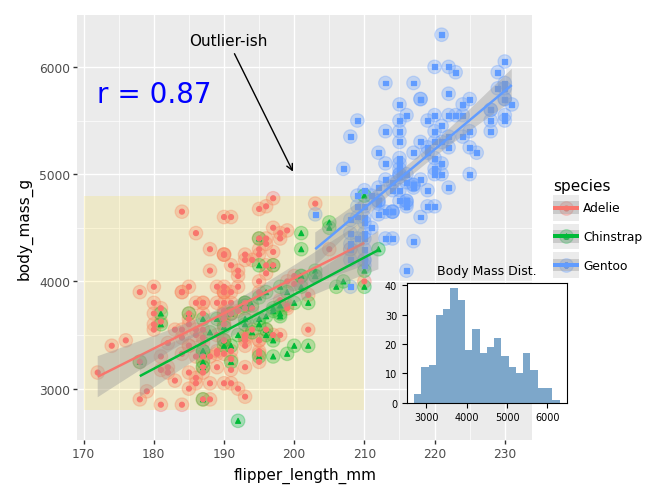

In [40]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline 
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from matplotlib.patches import Circle, Rectangle, FancyBboxPatch, Ellipse
from matplotlib.lines import Line2D

# Set random seed for reproducibility
np.random.seed(2026)

from plotnine import * 
from plotnine.data import anscombe_quartet 
from plotnine.data import penguins 

p = ggplot(anscombe_quartet, aes(x="x", y="y")) + geom_point()


plt.close('all')
#generating r coeficient for the plots (overall for all penquins)
r_coef = penguins["flipper_length_mm"].corr(penguins["body_mass_g"])

p1=(#composition functionality
    ggplot(penguins, aes(x="flipper_length_mm"
                         #or:
                         #x="bill_length_mm / bill_depth_mm"#
                         , y="body_mass_g"
                         , color="species"#color automatically creates groups
                                                                #groups="species for same effect sans color
                                                                #applies to all geoms
                        ))
    + geom_point(size=5, alpha=.3,)#literal mapphings, passing value directly to geom
    + geom_point(aes(shape="species"))           # shape points
    + geom_smooth(method="lm")
    + annotate(#add r coefficient as annotations
    "text",
    x=180,
    y=5750,
    label=f"r = {r_coef:.2f}",
    color="blue",
    size=20,
    )
)

fig=p1.draw()


#add highlight
from matplotlib.patches import Rectangle

ax = fig.axes[0]
ax.add_patch(Rectangle((170, 2800), 40, 2000,
                       facecolor="gold", alpha=0.15, edgecolor="none"))

#add annotations(not appaering?)
ax.annotate(
    "Outlier-ish",
    xy=(200, 5000),        # <-- pick a point in your data range
    xytext=(185, 6200),    # <-- where the label goes
    arrowprops=dict(arrowstyle="->", lw=1),
    fontsize=11
)
#inset axes
# Get the main axes position (so we anchor relative to it)
bbox = ax.get_position()

# Create a new axes in figure coordinates
ax_hist = fig.add_axes([
    bbox.x1 - 0.38,   # move left from right edge of main plot
    bbox.y1 - 0.82,   # move down from top
    0.25,             # width
    0.25              # height
])

# Plot histogram
ax_hist.hist(
    penguins["body_mass_g"].dropna(),
    bins=20,
    color="steelblue",
    alpha=0.7
)

ax_hist.set_title("Body Mass Dist.", fontsize=9)
ax_hist.tick_params(labelsize=7)


fig #fig.show() or plt.show don;t work here

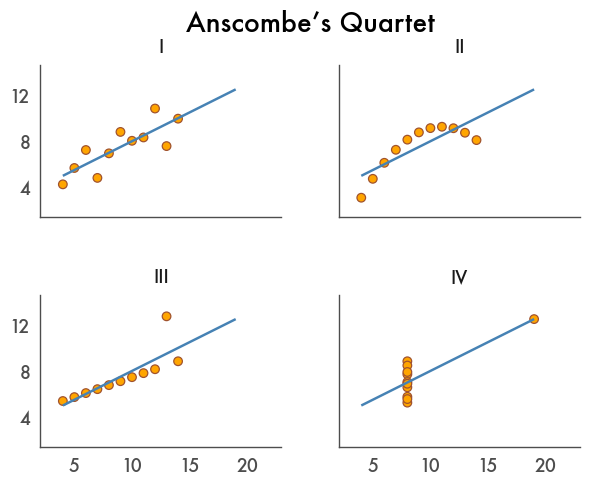

In [4]:
plt.close('all')
p=(
    ggplot(anscombe_quartet, aes("x", "y"))
    + geom_point(color="sienna", fill="orange", size=3)
    + geom_smooth(method="lm", se=False, fullrange=True,
                  color="steelblue", size=1)
    + facet_wrap("dataset")
    + labs(title="Anscombe’s Quartet")
    + scale_y_continuous(breaks=(4, 8, 12))
    + coord_fixed(xlim=(3, 22), ylim=(2, 14)) 
    + theme_tufte(base_family="Futura", base_size=16)
    + theme(
        axis_line=element_line(color="#4d4d4d"),
        axis_ticks_major=element_line(color="#00000000"),
        axis_title=element_blank(),
        panel_spacing=0.09,
    )
)

fig = p.draw()






fig #fig.show() or plt.show don;t work here


In [5]:
print(anscombe_quartet.head())
print(anscombe_quartet.columns)
anscombe_quartet.head()

  dataset   x     y
0       I  10  8.04
1       I   8  6.95
2       I  13  7.58
3       I   9  8.81
4       I  11  8.33
Index(['dataset', 'x', 'y'], dtype='object')


,dataset,x,y
0,I,10,8.04
1,I,8,6.95
2,I,13,7.58
3,I,9,8.81
4,I,11,8.33


In [6]:
  dataset   x     y
0       I  10  8.04
1       I   8  6.95
2       I  13  7.58
3       I   9  8.81
4       I  11  8.33
Index(['dataset', 'x', 'y'], dtype='object')
dataset	x	y
0	I	10	8.04
1	I	8	6.95
2	I	13	7.58
3	I	9	8.81
4	I	11	8.33



IndentationError: unexpected indent (1957416322.py, line 1)

### Overview of use

/Users/evijonas/python/archyviz/lib/python3.14/site-packages/plotnine/stats/stat_bin.py:112: PlotnineWarning: 'stat_bin()' using 'bins = 17'. Pick better value with 'binwidth'.


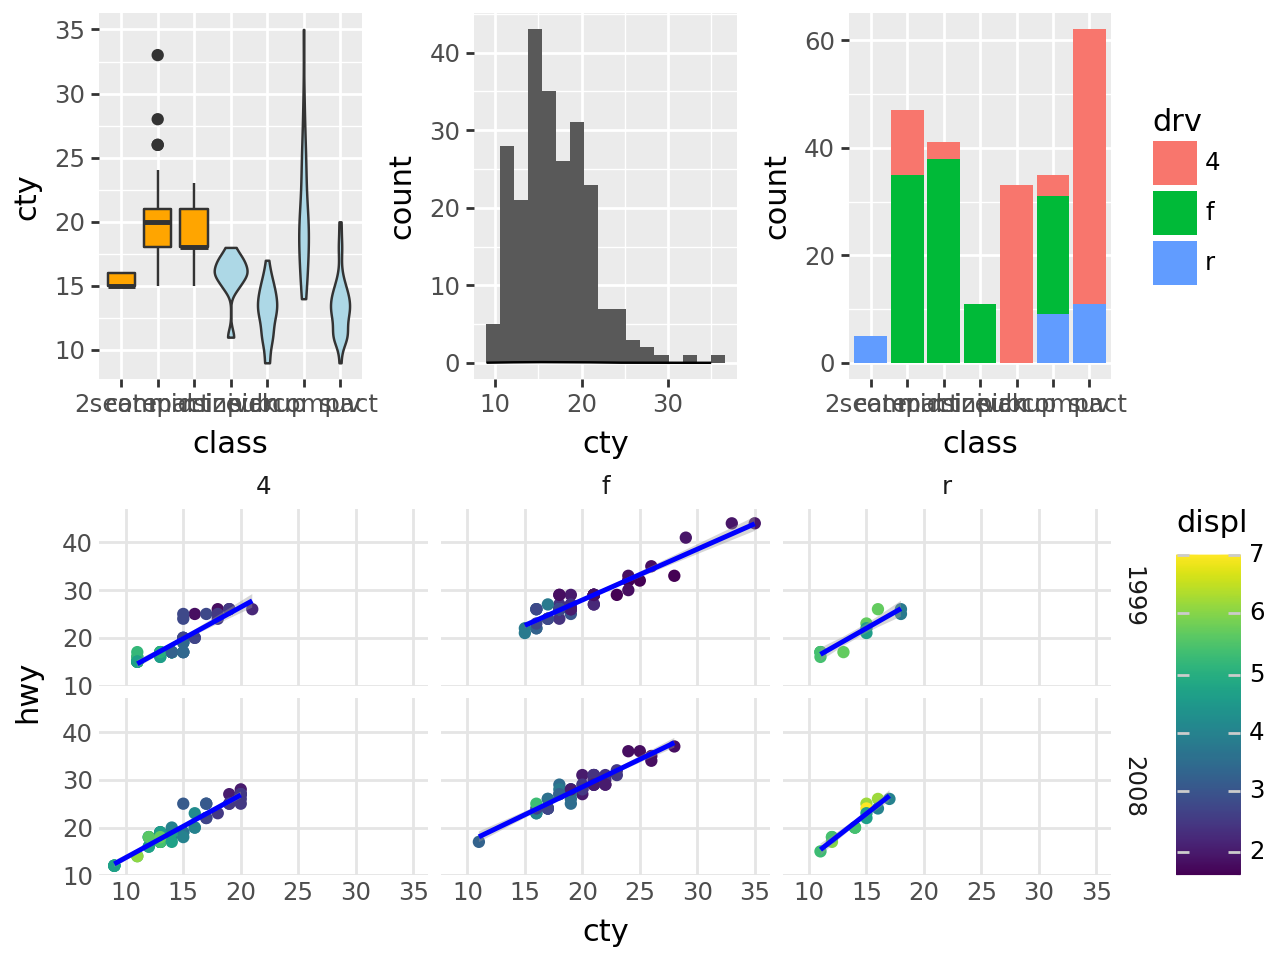

In [7]:
from plotnine import *
from plotnine.data import mpg

#ggplot(data=mpg, mapping=aes(x="cty", y="hwy"))
p1 = (
    ggplot(mpg, aes("cty", "hwy"))
    + geom_point(mapping=aes(colour="displ"))
    + geom_smooth(method="lm", color="blue")
    + scale_color_continuous(cmap_name="viridis")
    + facet_grid("year ~ drv") # Facetting by two variables
    #+ coord_fixed() #to ensure the x- and y-axes have the same spacing.
    #+ coord_cartesian(ylim=[50, -50])#allows to control zoom
    #+ coord_flip()#flips 90 degrees clockwise by default
    + theme_minimal()
    + theme(panel_grid_minor=element_blank())#idk
)

#box and violin
indx = mpg["class"].isin(["2seater", "compact", "midsize"])
p2 = (
    ggplot(aes("class", "cty"))
    + geom_boxplot(data=mpg[indx], fill="orange")
    + geom_violin(data=mpg[~indx], fill="lightblue")
)

#histogram
p3 = (
    ggplot(mpg, aes("cty"))
    + geom_histogram()
    + geom_density(fill="lightblue")
)



#bar chart
ttl_mpg_class = mpg.value_counts(["class", "drv"]).reset_index()
ttl_mpg_class.head(3)
p4 = (
    ggplot(ttl_mpg_class, aes("class", "count", fill= "drv")) 
    + geom_col()
)

(p2 | p3 | p4) / (p1)#squishes the first three together and lets the last one (p1) be big and witde

## aes mappings

## Below we mess around with someones else' code to figure out .draw() extraction
 - BIG don't uncollapse \
Rennie, Nicola. 2024. “Annotated Area Charts with Plotnine.” July 11, 2024. https://nrennie.rbind.io/blog/plotnine-annotated-area-chart/.

/var/folders/v7/7vfbdgg12c39wdwbk95gjb000000gn/T/ipykernel_10096/3570517139.py:194: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


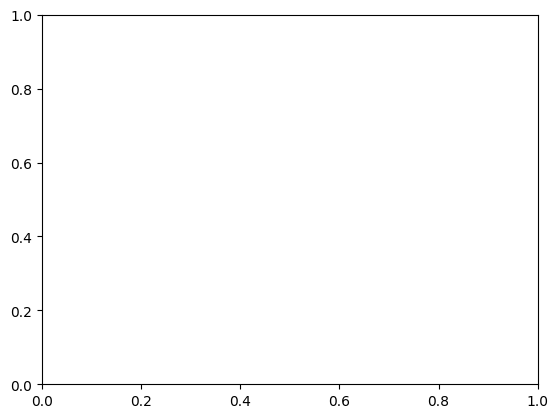

In [8]:
import plotnine as gg
import pandas as pd
import textwrap
import matplotlib.pyplot as plt
#import highlight_text as ht
import matplotlib.font_manager

emissions = pd.read_csv(
    'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2024/2024-05-21/emissions.csv')

# Prep data for plotting
plot_data = emissions[
    emissions['commodity'].isin([
        'Sub-Bituminous Coal', 'Metallurgical Coal', 'Bituminous Coal',
        'Thermal Coal', 'Anthracite Coal', 'Lignite Coal'
    ])
].copy()
plot_data['commodity'] = plot_data['commodity'].str.replace(' Coal', '')

# Total production per year since 1900
plot_data = plot_data[['year', 'commodity', 'production_value']]
plot_data = plot_data.groupby(['year', 'commodity'], as_index=False).agg(
    {'production_value': 'sum'}).rename(columns={'production_value': 'n'})
plot_data = plot_data[plot_data['year'] >= 1900]

# Sort values by 2022 levels
orders = plot_data[plot_data['year'] == 2022].sort_values(
    by='n', ascending=False)['commodity']
plot_data['commodity'] = pd.Categorical(
    plot_data['commodity'],
    categories=orders,
    ordered=True)


# Values for annotations
exceeds100 = plot_data.groupby('year')['n'].sum()
exceeds100 = exceeds100[exceeds100 > 100].index.min()

# Create data for x-axis labels
segment_data = pd.DataFrame({
    'year': list(range(1900, 2021, 20))
})

# y-axis labels
y_axis_data = pd.DataFrame({
    'value': [0, 2000, 4000, 6000, 8000],
    'label': ['0', '2,000', '4,000', '6,000', '8,000\nmillion\ntonnes']
})

# Available fonts
flist = matplotlib.font_manager.findSystemFonts()

# Check if 'Arial' in list of installed fonts
flist = ''.join(flist).lower()
if 'arial' in flist:
    body_font = 'Arial'
else:
    body_font = 'sans'


# title, subtitle
title_text = 'Coal production since 1900'
st = 'Carbon Majors is a database of historical production data from 122 of the world’s largest oil, gas, coal, and cement producers. This data is used to quantify the direct operational emissions and emissions from the combustion of marketed products that can be attributed to these entities.'
wrapped_subtitle = '\n'.join(textwrap.wrap(st, width=50))

# annotation labels
coal_types_label = 'Total coal production includes\nproduction of <Bituminous::{"color": "#E58606"}>,\n<Sub-bituminous::{"color": "#5D69B1"}>, <Metallurgical::{"color": "#52BCA3"}>,\n<Lignite::{"color": "#99C945"}>, <Anthracite::{"color": "#CC61B0"}>, and <Thermal::{"color": "#24796C"}>\ncoal. Bituminous accounts\nfor around half.'

# caption
cap = '<Data::{"fontweight": "bold"}>: Carbon Majors\n<Graphic::{"fontweight": "bold"}>: Nicola Rennie (@nrennie)'

p = (gg.ggplot(plot_data, gg.aes(x='year', y='n')))

p = (p +
     # Axis lines
     gg.geom_segment(data=segment_data, mapping=gg.aes(x='year', xend='year', y=0, yend=-1700),
                     linetype='dashed', alpha=0.4, color='blue') +
     # Axis labels
     gg.geom_text(data=segment_data, mapping=gg.aes(x='year', y=-1900, label='year'),
                  color='blue', size=8, family=body_font, ha='left') +
     gg.geom_text(data=y_axis_data, mapping=gg.aes(x=2023, y='value', label='label'),
                  color='blue', size=8, family=body_font, ha='left', va='top'))

p = (p +
     # Annotation 1
     gg.annotate(
         'segment',
         x=exceeds100, xend=exceeds100,
         y=0, yend=5000,
         size=1,
         color='blue'
) +
    gg.annotate(
         'text',
         x=exceeds100 + 2, y=5000,
         label=exceeds100,
         color='blue',
         family=body_font,
         ha='left',
         va='top',
         size=10,
         fontweight='bold'
) +
    gg.annotate(
         'text',
         x=exceeds100 + 2, y=5000 - 600,
         label='Total coal production first\nexceeds 100 million tonnes\nper year.',
         color='blue',
         family=body_font,
         ha='left',
         size=9,
         va='top'
) +
    # Annotation 2
    gg.annotate(
         'segment',
         size=1,
         x=1975, xend=1975,
         y=0, yend=10000,
         color='blue'
) +
    gg.annotate(
         'text',
         x=1975 + 2, y=10000,
         label='Coal types',
         color='blue',
         family=body_font,
         ha='left',
         va='top',
         size=10,
         fontweight='bold'
))

p = (p +
    # Add area plot
    gg.geom_area(gg.aes(fill='commodity')) +
    # Colour, x-axis, and y-axis scales
    gg.scale_fill_manual(values=['#E58606', '#5D69B1', '#52BCA3',
            '#99C945', '#CC61B0', '#24796C']) +
    gg.scale_x_continuous(limits=(1896, 2034)) +
    gg.scale_y_continuous(limits=(-3300, 12000)) +
    # Text for title and subtitle
    gg.annotate(
         'text',
         x=1900, y=11400,
         label=title_text,
         color='blue',
         family=body_font,
         ha='left',
         va='top',
         size=13,
         fontweight='bold'
) +
    gg.annotate(
         'text',
         x=1900, y=10500,
         label=wrapped_subtitle,
         color='blue',
         family=body_font,
         size=9.5,
         ha='left',
         va='top'
))

p = (p +
    # Styling
    gg.coord_cartesian(expand=False) +
    gg.theme_void(base_size=8) +
    gg.theme(
         legend_position='none',
         plot_background=gg.element_rect(fill='grey', color='grey'),
         panel_background=gg.element_rect(fill='yellow', color='orange')
))

# Add coloured text with matplotlib and highlight-text
# Convert to matplotlib and set plot options
fig = p.draw()
fig.set_size_inches(8, 6, forward=True)
ax = plt.gca()
# add coloured text to annotation
# ht.ax_text(
#     1977,
#     9400,
#     coal_types_label,
#     vsep=3,
#     color='blue',
#     fontname=body_font,
#     fontsize=9,
#     va='top')
# add caption
#ht.ax_text(1900, -2300, cap, color='blue',
#           fontname=body_font, fontsize=7.5, va='top')
p
fig.show()

/Users/evijonas/python/archyviz/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 2 rows containing missing values.
/Users/evijonas/python/archyviz/lib/python3.14/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_point : Removed 2 rows containing missing values.


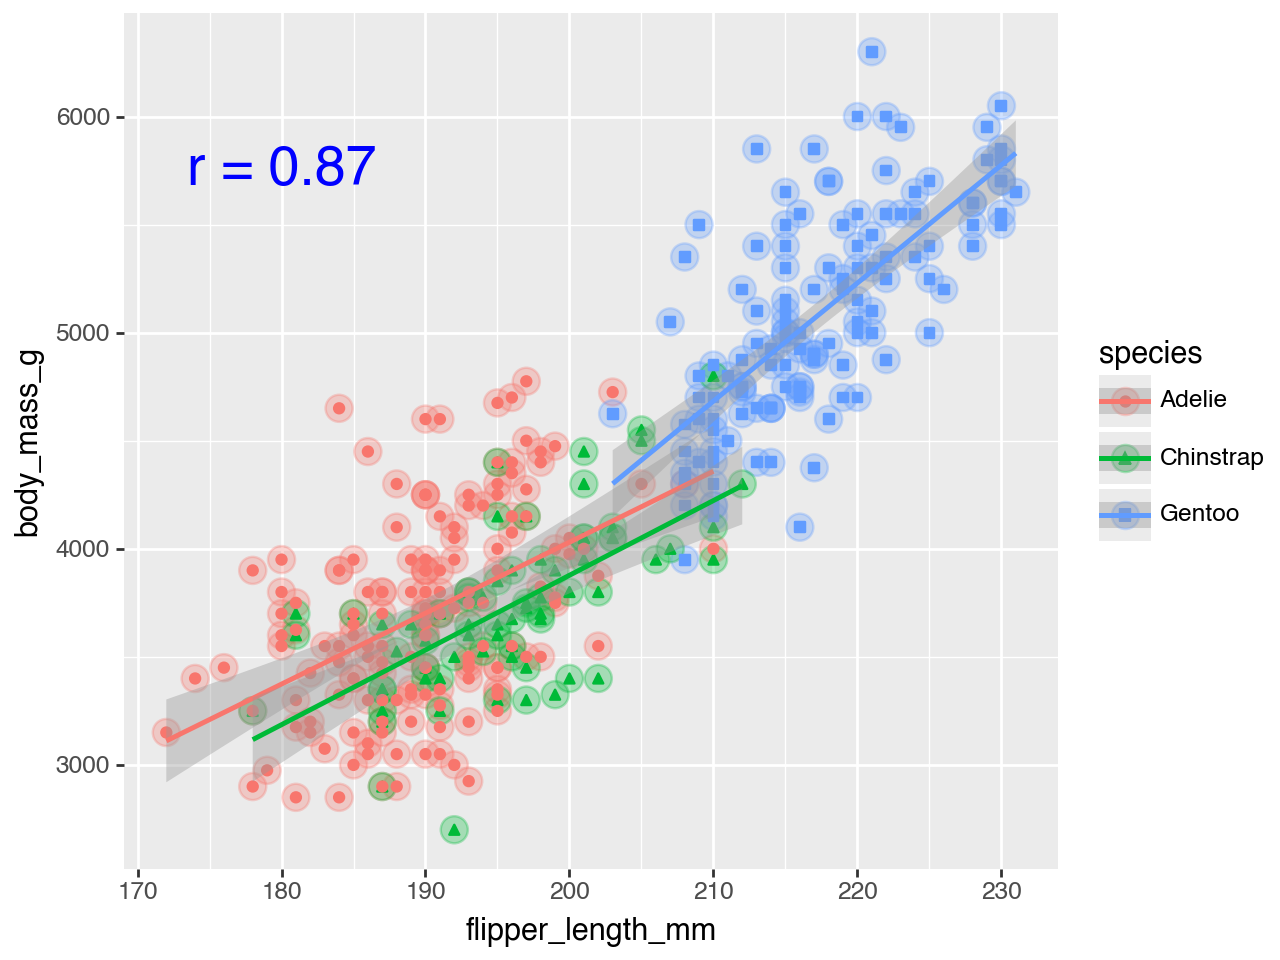

In [9]:
from plotnine import ggplot, aes, geom_point, geom_smooth
from plotnine.data import penguins

#generating r coeficient for the plots (overall for all penquins)
r_coef = penguins["flipper_length_mm"].corr(penguins["body_mass_g"])

(#composition functionality
    ggplot(penguins, aes(x="flipper_length_mm"
                         #or:
                         #x="bill_length_mm / bill_depth_mm"#
                         , y="body_mass_g"
                         , color="species"#color automatically creates groups
                                                                #groups="species for same effect sans color
                                                                #applies to all geoms
                        ))
    + geom_point(size=5, alpha=.3,)#literal mapphings, passing value directly to geom
    + geom_point(aes(shape="species"))           # shape points
    + geom_smooth(method="lm")
    + annotate(#add r coefficient as annotations
    "text",
    x=180,
    y=5750,
    label=f"r = {r_coef:.2f}",
    color="blue",
    size=20,
    )
)



## Geoms
-  gonna put in a lot of plots
-  ill facet them after and make that the deomstration of facetting
-  or compose them together to display that

In [10]:
from plotnine import *
from plotnine.data import mpg

#### they got rectangles

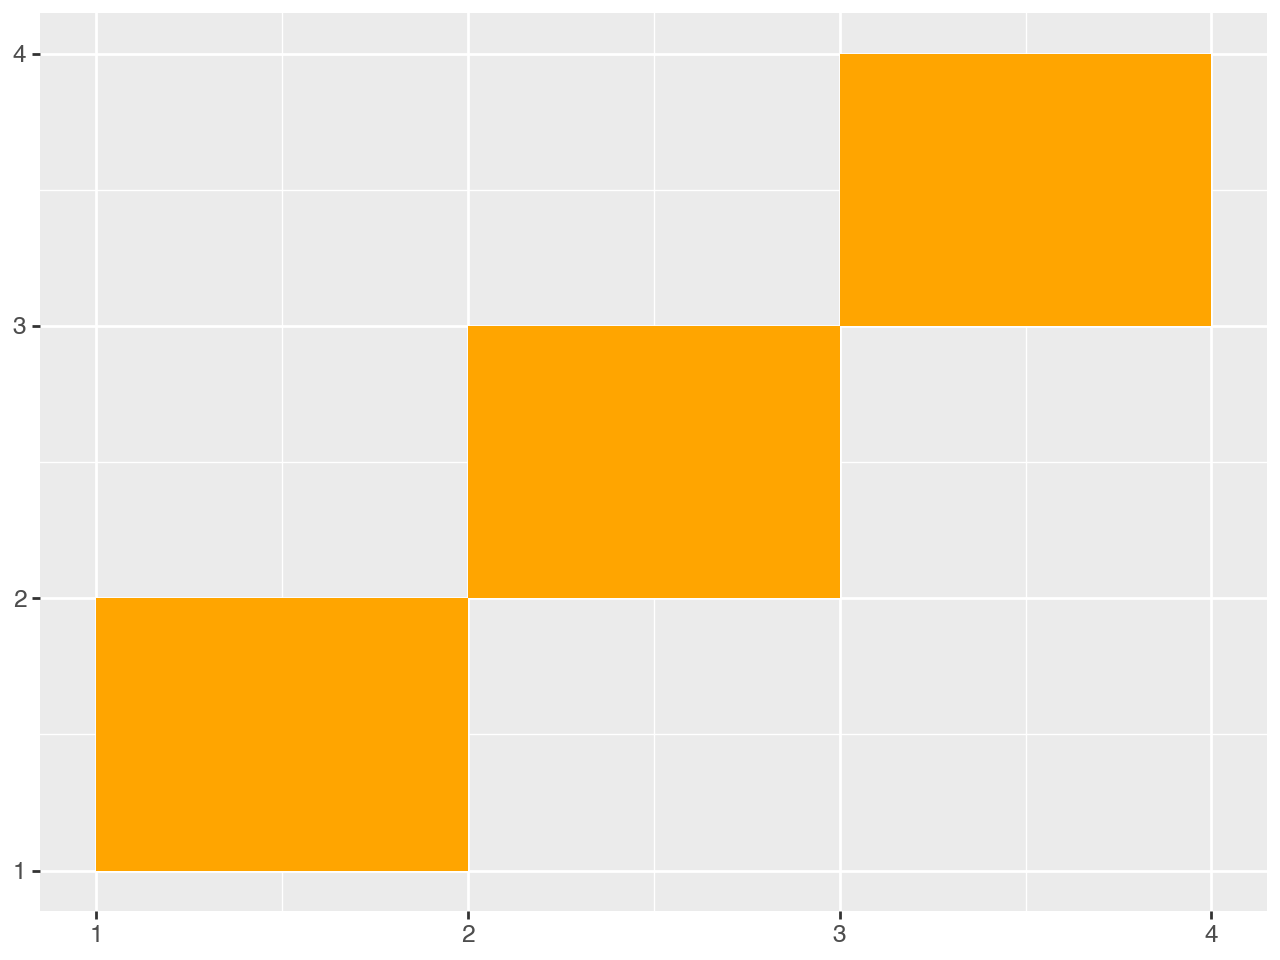

In [11]:
import pandas as pd

df_rect = pd.DataFrame(
    {
        "xmin": [1, 2, 3],
        "ymin": [1, 2, 3],
        "xmax": [2, 3, 4],
        "ymax": [2, 3, 4],
    }
)

(
    ggplot(df_rect, aes(xmin="xmin", ymin="ymin", xmax="xmax", ymax="ymax"))
    + geom_rect(fill="orange")
)

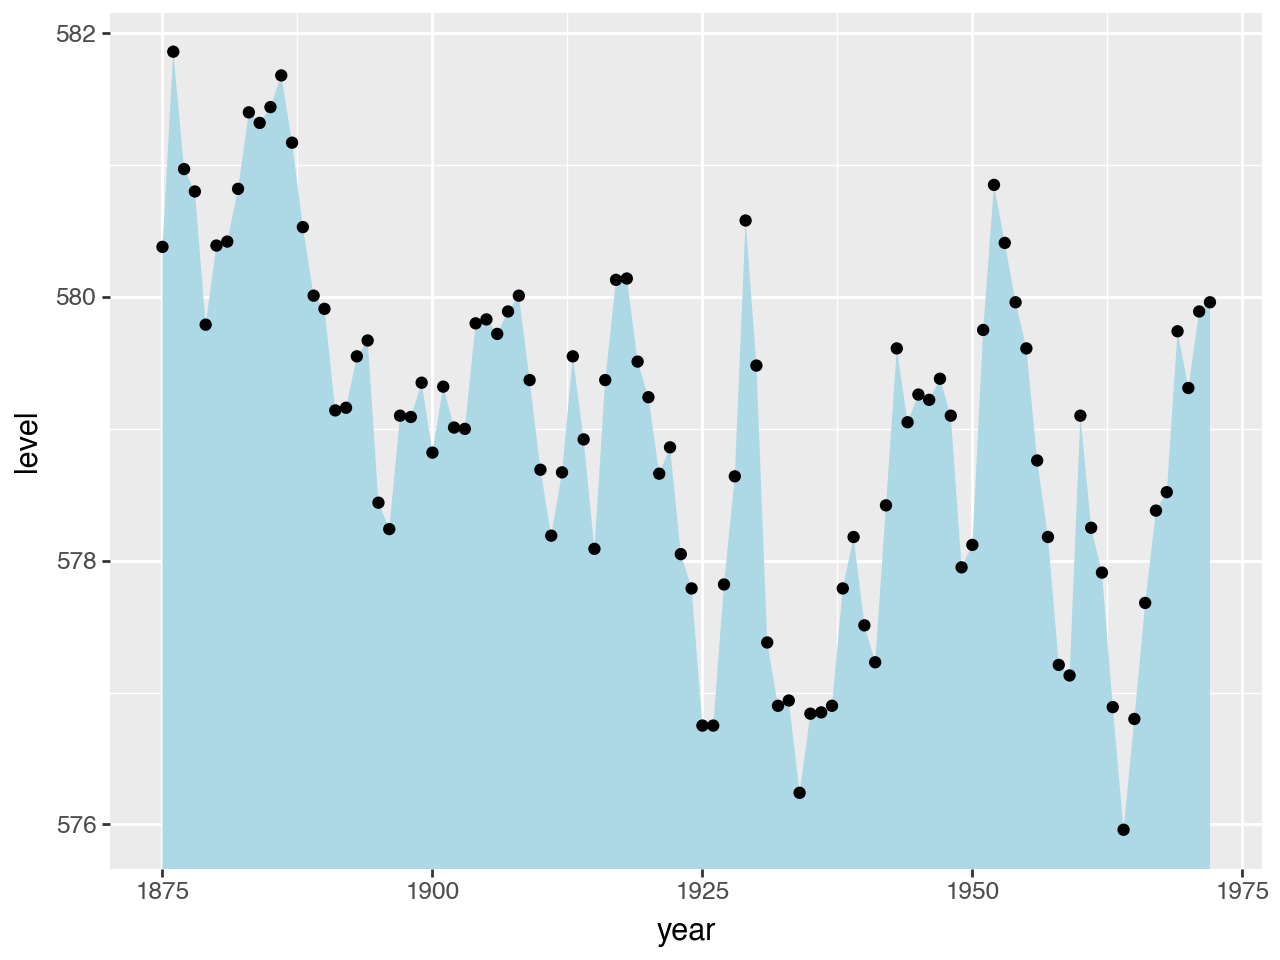

In [12]:
#line w fill
from plotnine import *
from plotnine.data import huron

(
    ggplot(huron, aes("year", "level"))
    + geom_ribbon(aes(ymax="level"), ymin=0, fill="lightblue")#fills in below a line
    + geom_point()
)

## Position adjustments

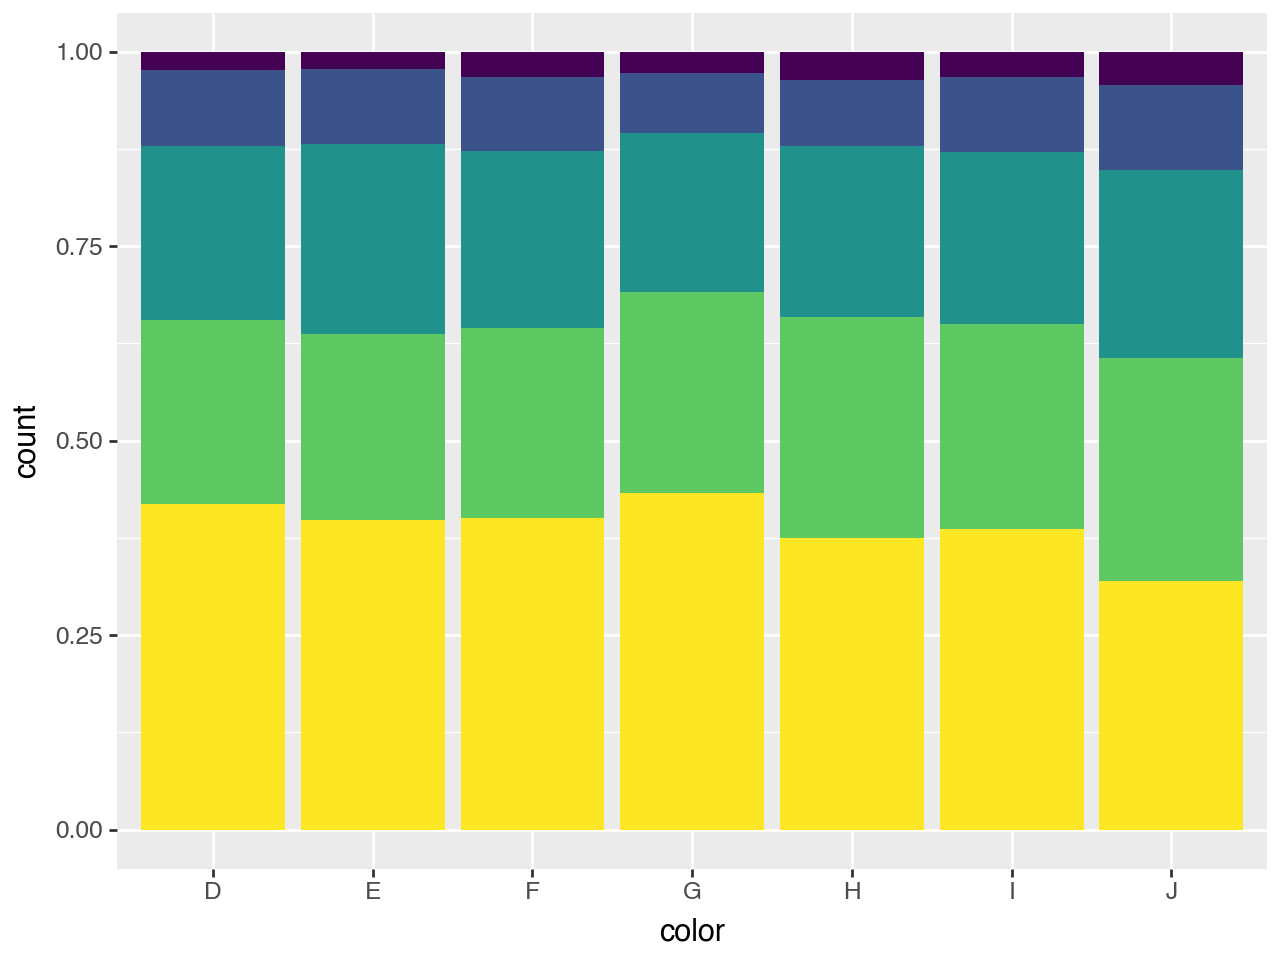

In [13]:
from plotnine import *
from plotnine.data import diamonds

p = ggplot(diamonds, aes("color", fill="cut")) + theme(legend_position="none")

p + geom_bar(position=position_stack())  # default
p + geom_bar(position=position_fill()) #equalizes heigh
#p + geom_bar(position=position_dodge())
# come back and facet these together


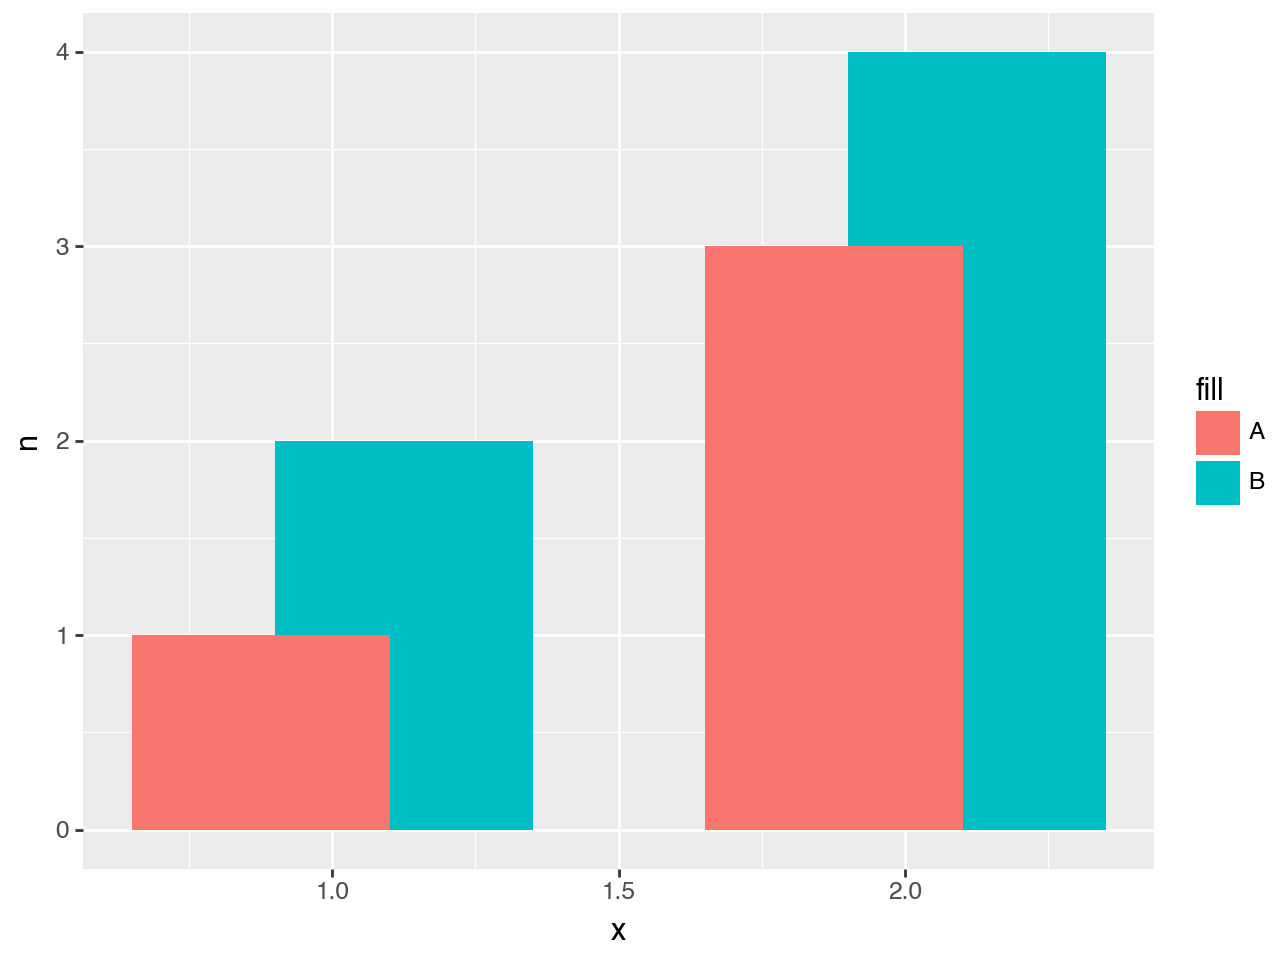

In [14]:
# spacing between dodged bars
import pandas as pd

df = pd.DataFrame({"x": [1, 1, 2, 2], "n": [1, 2, 3, 4], "fill": ["A", "B"] * 2})

p1 = ggplot(df, aes("x", "n", fill="fill")) + geom_col(position=position_dodge(width=0.5))

dodge = position_dodge(width=0.6)#dodge moves bars side by side
p2 = (
    ggplot(df, aes("x", "n", fill="fill", label="n"))
    + geom_col(position=dodge, width=0.5)
    + geom_text(position=dodge)
)

(p1 ) #| p2)#you can turn these on or off individualy


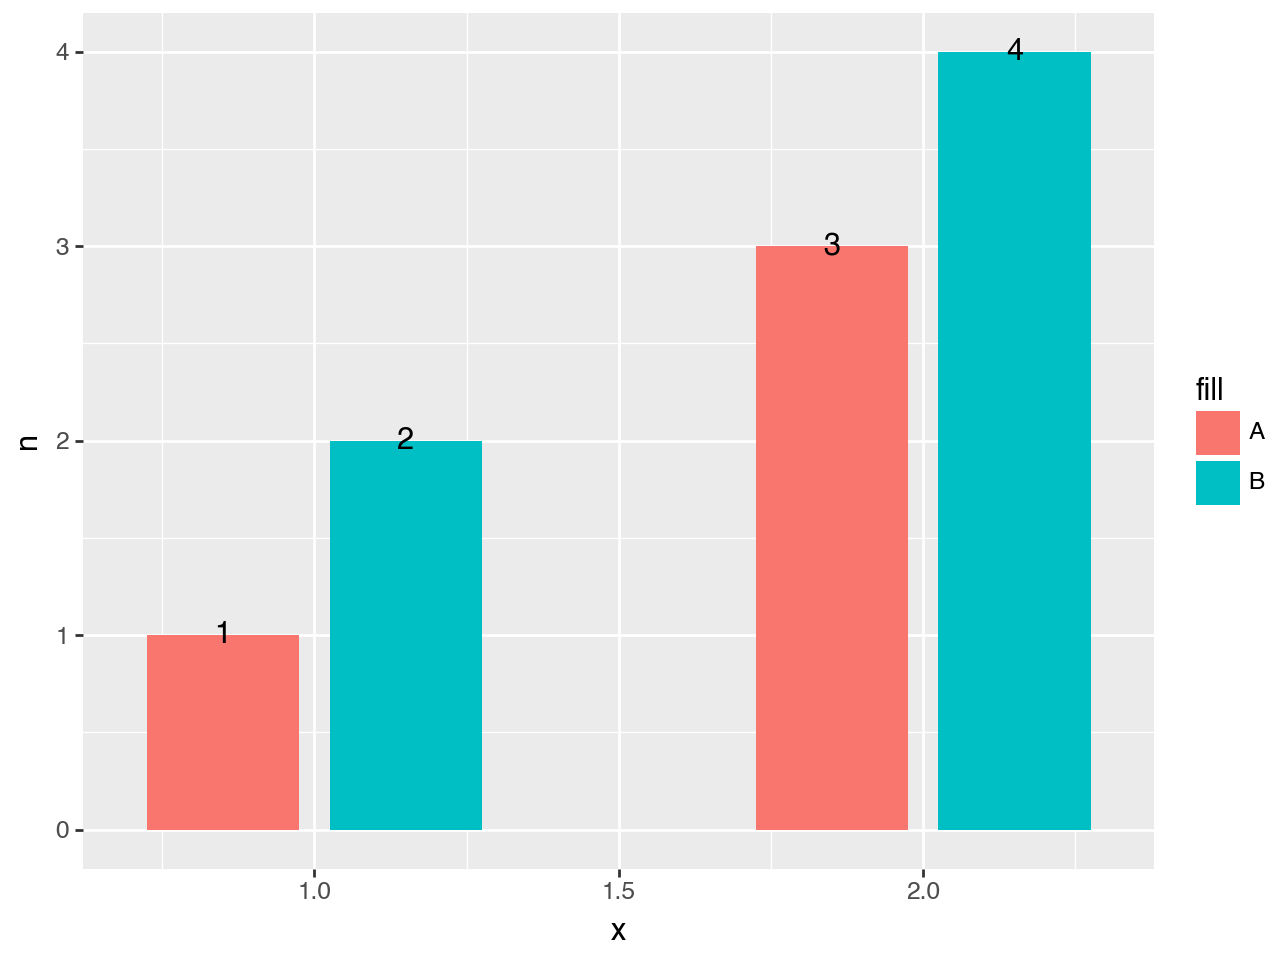

In [15]:
dodge = position_dodge(width=0.6)
(
    ggplot(df, aes("x", "n", fill="fill", label="n"))
    + geom_col(position=dodge, width=0.5)
    + geom_text(position=dodge)
)

## And maps!
-  they dont work in this notebook

In [16]:
import geopandas as gp
import geodatasets

chicago = gp.read_file(geodatasets.get_path("geoda.chicago_commpop"))
groceries = gp.read_file(geodatasets.get_path("geoda.groceries"))

crs_groceries = groceries.to_crs(chicago.crs)

(
    ggplot()
    + geom_map(data=chicago, fill=None)
    + geom_map(data=crs_groceries, color="green")
    + theme_void()
    + coord_fixed()
)
#DOESNT WORK

ModuleNotFoundError: No module named 'geodatasets'